In [38]:
import pandas as pd
import statistics as stat

df = pd.read_csv("cleaned_dataset.csv")

def predict_delay(depart_stat: str, arrival_stat: str) -> int:
    index = 0
    depart_stat_tab = [1]
    arrival_stat_tab = [1]
    while (index < 10000):
        if (df["Departure station"][index] == depart_stat):
            depart_stat_tab.append(df["Average delay of all trains at departure"][index])
        if (df["Arrival station"][index] == arrival_stat):
            arrival_stat_tab.append(df["Average delay of all trains at departure"][index])
        index += 1
    depart_stat_const = stat.mean(depart_stat_tab)
    arrival_stat_const = stat.mean(arrival_stat_tab)
    depart_stat_pred = 1
    arrival_stat_pred = 1
    intercept = 0
    delay_time = intercept + depart_stat_const * depart_stat_pred + arrival_stat_const * arrival_stat_pred
    return delay_time

print(predict_delay("LE MAN", "PARIS EST"))



4.247050448856449


Proof of concept : exemples of how a linear regression works

[[16.94392576]
 [96.87284793]
 [79.26723771]
 [76.60192429]
 [72.09793836]
 [18.92583815]
 [ 1.05298564]
 [76.78560021]
 [65.9863539 ]
 [33.29096325]
 [ 5.09740579]
 [84.79849938]
 [37.90850519]
 [ 4.41698639]
 [38.31485667]
 [81.16240419]
 [62.73185587]
 [68.97834738]
 [16.77186445]
 [54.54000302]
 [82.7490056 ]
 [76.20796852]
 [22.65810628]
 [ 6.77363481]
 [54.10011699]
 [76.59693743]
 [25.04483226]
 [64.47307429]
 [97.95990502]
 [43.74385349]
 [56.77974924]
 [54.82313309]
 [61.24236675]
 [85.61176215]
 [56.47147777]
 [94.13004151]
 [38.18972062]
 [50.97365486]
 [94.90108932]
 [90.21611579]
 [92.68586896]
 [68.48192977]
 [21.81354299]
 [15.71240218]
 [25.6335003 ]
 [ 3.62429665]
 [41.03729354]
 [32.81269823]
 [ 8.42028415]
 [57.01540008]
 [13.5352812 ]
 [77.64712853]
 [ 5.58563709]
 [91.75524747]
 [45.14577801]
 [86.81197476]
 [39.87341093]
 [82.24785421]
 [26.87108512]
 [89.52677229]
 [18.47264491]
 [19.18614298]
 [28.24431457]
 [33.5020261 ]
 [49.20260546]
 [12.43630441]
 [22.32340

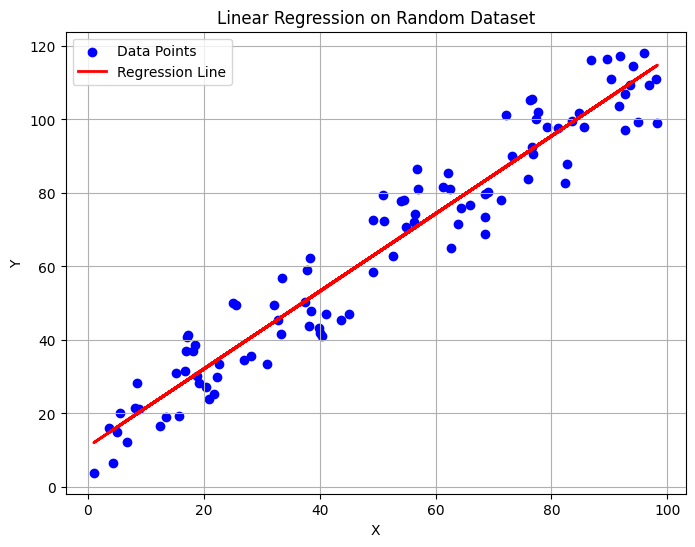

Slope (Coefficient): 1.0569184016142095
Intercept: 10.929960277490686


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.random.rand(100, 1) * 100  
Y = X + np.random.rand(100, 1) * 30

model = LinearRegression()
model.fit(X, Y)

Y_pred = model.predict(X)

plt.figure(figsize=(8,6)) 
plt.scatter(X, Y, color='blue', label='Data Points') 
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

print("Slope (Coefficient):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])


In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("cleaned_dataset.csv")

def predict_delay_with_model(depart_stat: str, arrival_stat: str) -> int:
    index = 0
    occ = 0
    X = []
    Y = []
    while (index < 10000):
        if (df["Departure station"][index] == depart_stat):
            X.append(df["Average delay of all trains at departure"][index]) 
            occ += 1
        index += 1
    print(X)
    Y = X + np.random.rand(occ, 1) * occ
    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    plt.figure(figsize=(8,6)) 
    plt.scatter(X, Y, color='blue', label='Data Points') 
    plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line') 
    plt.title('Linear Regression on Random Dataset')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Slope (Coefficient):", model.coef_[0][0])
    print("Intercept:", model.intercept_[0])

predict_delay_with_model("LE MANS", "PARIS EST")

[np.float64(4.567119342), np.float64(4.263594041), np.float64(3.012614871), np.float64(3.963991081), np.float64(4.665509989), np.float64(5.563841808), np.float64(6.700957854), np.float64(3.385160428), np.float64(2.980548303), np.float64(4.318069728), np.float64(4.224542125), np.float64(4.293774626), np.float64(5.910989811), np.float64(3.38764988), np.float64(4.384688995), np.float64(4.341254902), np.float64(2.790508221), np.float64(5.034770785), np.float64(2.495), np.float64(4.174174528), np.float64(9.228577441), np.float64(5.36448749), np.float64(5.426585366), np.float64(4.16037464), np.float64(4.112953586), np.float64(4.39371293), np.float64(2.149679487), np.float64(7.02457483), np.float64(4.367784257), np.float64(3.701837607), np.float64(4.493916024), np.float64(2.073923445), np.float64(6.047987421), np.float64(3.377358491), np.float64(4.016716567), np.float64(3.97688422688423), np.float64(4.5), np.float64(1.99527491408935), np.float64(1.42760416666667), np.float64(2.29372807017544)

ValueError: Expected 2D array, got 1D array instead:
array=[4.56711934 4.26359404 3.01261487 3.96399108 4.66550999 5.56384181
 6.70095785 3.38516043 2.9805483  4.31806973 4.22454213 4.29377463
 5.91098981 3.38764988 4.384689   4.3412549  2.79050822 5.03477079
 2.495      4.17417453 9.22857744 5.36448749 5.42658537 4.16037464
 4.11295359 4.39371293 2.14967949 7.02457483 4.36778426 3.70183761
 4.49391602 2.07392345 6.04798742 3.37735849 4.01671657 3.97688423
 4.5        1.99527491 1.42760417 2.29372807 3.54       5.71397849
 4.14591503 4.61952141 0.         3.29238729 2.87773946 2.89
 2.58122807 3.2109058  2.98593862 2.95938865 4.48800959 3.5
 3.82690318 7.06757444 3.98864511 6.26321705 3.63124066 3.163382
 3.94522569 4.87786759 5.04038978 4.87561594 6.49496296 3.29198113
 7.31512213 5.15       4.15326868 4.15230382 3.01985816 5.74578103
 3.52350427 2.51701389 4.92404608 5.29674419 6.58150312 7.10884643
 5.69952381 4.62359882 7.11677373].
Reshape your data either using array.reshape(-1, 